# 02: Viabilidade, avaliação, robustez e explicabilidade

Este notebook carrega o `ModelBundle` produzido por `python -m pdm.cli train` (o mesmo
artefato que a API de inferência usa) e reproduz, com visualizações, a avaliação completa:
matriz de confusão, calibração, cobertura conformal, degradação sob robustez e explicabilidade.

Toda a lógica reaproveitada aqui vive em `src/pdm/evaluation/` e `src/pdm/models/pipeline.py`
(`evaluate_bundle_on_holdout` reconstrói exatamente o mesmo conjunto de teste usado no
treino, a partir da mesma seed, sem precisar retreinar nada). Ver
[`docs/01_interpretacao_problema.md`](../docs/01_interpretacao_problema.md) para a
interpretação dos números abaixo no contexto do case.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from pdm.config import load_config
from pdm.models.bundle import BUNDLE_FILENAME, ModelBundle
from pdm.models.pipeline import evaluate_bundle_on_holdout
from pdm.evaluation.metrics import confusion_matrix_df, evaluate_calibration, full_classification_report
from pdm.evaluation.conformal import average_set_size, coverage_by_class, empirical_coverage
from pdm.evaluation.imbalance import evaluate_under_prior
from pdm.evaluation.robustness import feature_group_ablation_test, sensor_dropout_test
from pdm.evaluation.explain import permutation_importance_report, shap_global_importance, SHAP_AVAILABLE

mpl.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

cfg = load_config()
bundle = ModelBundle.load(cfg.paths.models_dir / BUNDLE_FILENAME)
print(f"Modelo: {bundle.model_name}  Treinado em: {bundle.created_at}")
print(f"Sensores usados: {bundle.sensor_names}")
print(f"Métricas registradas no treino: ")
for k, v in bundle.metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo: hist_gradient_boosting  Treinado em: 2026-09-13T02:00:54.604257+00:00
Sensores usados: ['Dados_1', 'Dados_2', 'Dados_3']
Métricas registradas no treino: 
  cv_f1_macro_mean: 0.9568
  cv_f1_macro_std: 0.0018
  test_f1_macro: 0.9624
  test_ece: 0.0061
  conformal_coverage: 0.8944
  conformal_avg_set_size: 0.9816
  label_shuffle_control_f1: 0.2001
  noise_sensor_control_f1: 0.0667


In [2]:
holdout = evaluate_bundle_on_holdout(cfg, bundle)
X_test, y_test, y_pred, proba = holdout["X_test"], holdout["y_test"], holdout["y_pred"], holdout["proba"]
print(f"{len(y_test)} janelas no conjunto de teste, nunca vistas durante o treino")


/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: overflow encountered in scalar power
  b = fmax**(1/tmax) * (1/a)**(1/tmax)
/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: invalid value encountered in scalar multiply
  b = fmax**(1/tmax) * (1/a)**(1/tmax)


/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: overflow encountered in scalar power
  b = fmax**(1/tmax) * (1/a)**(1/tmax)
/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: invalid value encountered in scalar multiply
  b = fmax**(1/tmax) * (1/a)**(1/tmax)


/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: overflow encountered in scalar power
  b = fmax**(1/tmax) * (1/a)**(1/tmax)
/home/niko/pdm-test-clone/.venv/lib/python3.10/site-packages/ssqueezepy/ssqueezing.py:299: RuntimeWarning: invalid value encountered in scalar multiply
  b = fmax**(1/tmax) * (1/a)**(1/tmax)


5000 janelas no conjunto de teste, nunca vistas durante o treino


## Matriz de confusão e relatório por classe

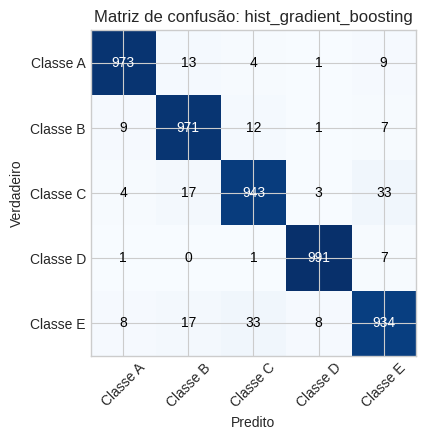

,precision,recall,f1-score,support
Classe A,0.978,0.973,0.975,1000.000
Classe B,0.954,0.971,0.962,1000.000
Classe C,0.950,0.943,0.946,1000.000
Classe D,0.987,0.991,0.989,1000.000
Classe E,0.943,0.934,0.939,1000.000
accuracy,0.962,0.962,0.962,0.962
macro avg,0.962,0.962,0.962,5000.000
weighted avg,0.962,0.962,0.962,5000.000


In [3]:
cm = confusion_matrix_df(y_test, y_pred, bundle.classes)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(bundle.classes))); ax.set_xticklabels(bundle.classes, rotation=45)
ax.set_yticks(range(len(bundle.classes))); ax.set_yticklabels(bundle.classes)
for i in range(len(bundle.classes)):
    for j in range(len(bundle.classes)):
        ax.text(j, i, cm.values[i, j], ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
ax.set_xlabel("Predito"); ax.set_ylabel("Verdadeiro")
ax.set_title(f"Matriz de confusão: {bundle.model_name}")
plt.tight_layout()
plt.show()

report = full_classification_report(y_test, y_pred, bundle.classes)
pd.DataFrame(report).T.round(3)


## Calibração

O erro de calibração esperado (ECE) mede se as probabilidades que o modelo reporta batem
com a frequência real de acerto, pré-requisito para a predição conformal abaixo fazer sentido.


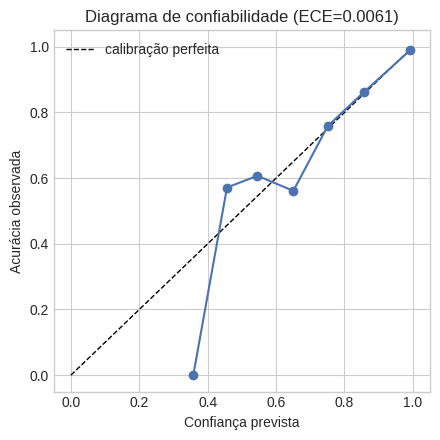

In [4]:
calibration = evaluate_calibration(y_test, proba, bundle.classes)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="calibração perfeita")
mask = calibration.bin_count > 0
ax.plot(calibration.bin_confidence[mask], calibration.bin_accuracy[mask], "o-", color="#4C72B0")
ax.set_xlabel("Confiança prevista"); ax.set_ylabel("Acurácia observada")
ax.set_title(f"Diagrama de confiabilidade (ECE={calibration.expected_calibration_error:.4f})")
ax.legend()
plt.tight_layout()
plt.show()


## Predição conformal: o sistema sabendo quando não sabe

O conjunto de predição conformal (`evaluation/conformal.py`) garante cobertura estatística
da classe verdadeira sem exigir que o modelo seja bayesiano. Um conjunto de tamanho 1 é uma
decisão confiante; um conjunto maior sinaliza ambiguidade real entre classes.

Referências: fundamentos da predição conformal (Vovk, Gammerman & Shafer, 2005, *Algorithmic Learning in a Random World*); o esquema *split conformal* com LAC e APS aleatorizado implementado em `evaluation/conformal.py` segue Romano, Sesia & Candès (2020, *Classification with Valid and Adaptive Coverage*).


Cobertura empírica: 0.8982 (alvo configurado: 0.9)
Tamanho médio do conjunto: 0.99
Cobertura por classe: {'Classe A': 0.903, 'Classe B': 0.895, 'Classe C': 0.912, 'Classe D': 0.895, 'Classe E': 0.886}


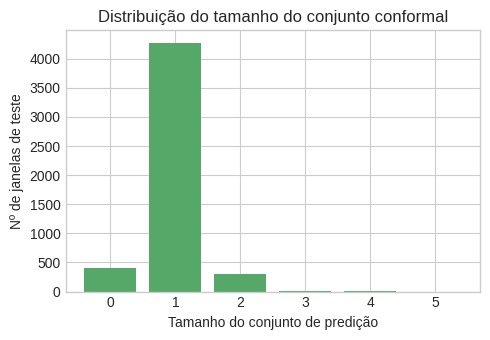

In [5]:
conformal_sets = holdout["conformal_sets"]
if conformal_sets is not None:
    coverage = empirical_coverage(conformal_sets, y_test, bundle.classes)
    avg_size = average_set_size(conformal_sets)
    per_class_cov = coverage_by_class(conformal_sets, y_test, bundle.classes)
    print(f"Cobertura empírica: {coverage:.4f} (alvo configurado: {cfg.conformal['target_coverage']})")
    print(f"Tamanho médio do conjunto: {avg_size:.2f}")
    print("Cobertura por classe:", {k: round(v, 3) for k, v in per_class_cov.items()})

    set_sizes = conformal_sets.sum(axis=1)
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.hist(set_sizes, bins=np.arange(0, len(bundle.classes) + 2) - 0.5, color="#55A868", rwidth=0.8)
    ax.set_xticks(range(len(bundle.classes) + 1))
    ax.set_xlabel("Tamanho do conjunto de predição")
    ax.set_ylabel("Nº de janelas de teste")
    ax.set_title("Distribuição do tamanho do conjunto conformal")
    plt.tight_layout()
    plt.show()


## Reavaliação sob um prior de classes realista

O conjunto do case está artificialmente balanceado. Aqui reamostramos o conjunto de teste
para simular a proporção configurada em `configs/default.yaml` (operação saudável dominante).


In [6]:
imbalance_eval = evaluate_under_prior(
    bundle.model, X_test, y_test, cfg.imbalance["simulated_prior"], bundle.classes, seed=cfg.random_seed
)
print(f"Amostras reamostradas: {imbalance_eval.n_samples}")
print(f"F1-macro sob o prior realista: {imbalance_eval.f1_macro:.4f}")
print("Recall por classe:", {k: round(v, 3) for k, v in imbalance_eval.recall_per_class.items()})
print("PR-AUC por classe:", {k: round(v, 3) for k, v in imbalance_eval.pr_auc_per_class.items()})


Amostras reamostradas: 1428
F1-macro sob o prior realista: 0.9354
Recall por classe: {'Classe A': 0.973, 'Classe B': 0.979, 'Classe C': 0.974, 'Classe D': 0.99, 'Classe E': 0.845}
PR-AUC por classe: {'Classe A': 1.0, 'Classe B': 0.987, 'Classe C': 0.991, 'Classe D': 0.999, 'Classe E': 0.924}


## Robustez: o que acontece quando um sensor cai, ou uma família de features falta

Testes de degradação medem o quanto o modelo já treinado depende de cada sensor e de cada
grupo de features, sem retreinar; a pergunta operacional real é "o que acontece se
`Dados_2` parar de mandar dado amanhã?".


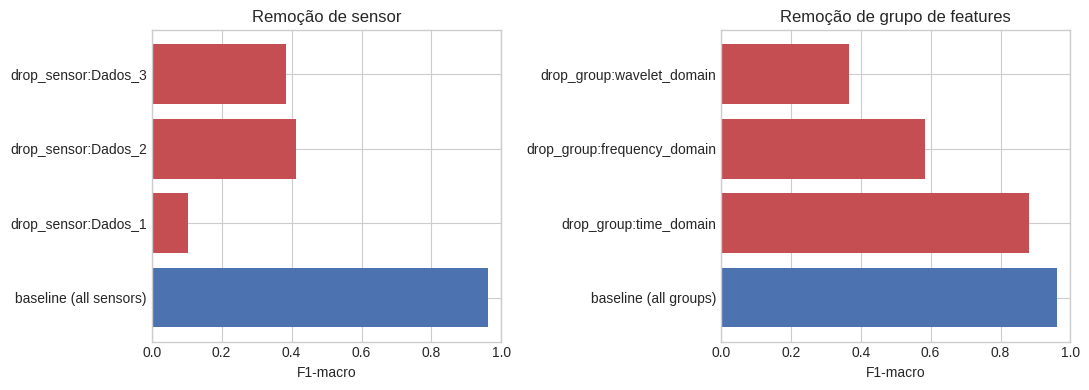

In [7]:
dropout = sensor_dropout_test(bundle.model, X_test, y_test, bundle.classes, bundle.sensor_names)
ablation = feature_group_ablation_test(bundle.model, X_test, y_test, bundle.classes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, results, title in zip(axes, [dropout, ablation], ["Remoção de sensor", "Remoção de grupo de features"]):
    labels = [r.scenario for r in results]
    values = [r.f1_macro for r in results]
    colors = ["#4C72B0"] + ["#C44E52"] * (len(results) - 1)
    ax.barh(labels, values, color=colors)
    ax.set_xlabel("F1-macro")
    ax.set_title(title)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## Explicabilidade

Importância por permutação está sempre disponível; SHAP é usado quando disponível
(ver `docs/03_arquitetura.md`, seção 3.6, sobre a política de dependências opcionais).

Referências: SHAP (Lundberg & Lee, 2017, *A Unified Approach to Interpreting Model Predictions*); LIME (Ribeiro, Singh & Guestrin, 2016, *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*).


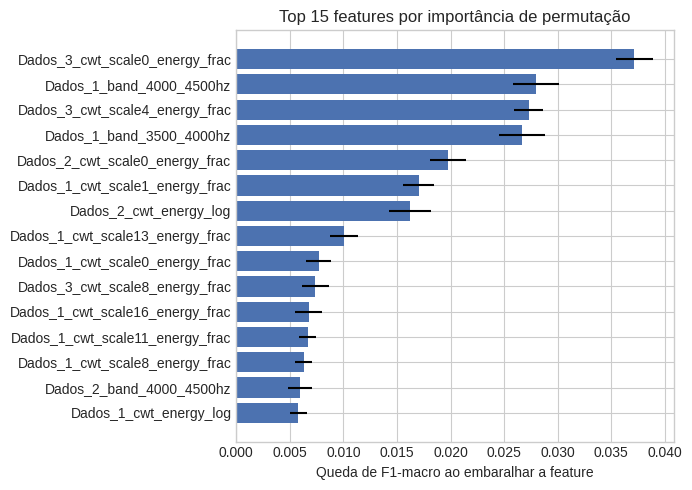

,feature,mean_abs_shap
0,Dados_1_band_3500_4000hz,0.664986
1,Dados_2_cwt_energy_log,0.518042
2,Dados_1_cwt_scale1_energy_frac,0.515394
3,Dados_1_band_4000_4500hz,0.484489
4,Dados_3_cwt_scale0_energy_frac,0.464166
5,Dados_2_cwt_scale0_energy_frac,0.392343
6,Dados_1_cwt_scale0_energy_frac,0.375344
7,Dados_3_cwt_scale4_energy_frac,0.336493
8,Dados_2_band_4000_4500hz,0.335365
9,Dados_1_cwt_scale13_energy_frac,0.332410


In [8]:
perm_importance = permutation_importance_report(bundle.model, X_test, y_test, n_repeats=10, seed=cfg.random_seed)
top15 = perm_importance.head(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top15["feature"][::-1], top15["importance_mean"][::-1], xerr=top15["importance_std"][::-1], color="#4C72B0")
ax.set_xlabel("Queda de F1-macro ao embaralhar a feature")
ax.set_title("Top 15 features por importância de permutação")
plt.tight_layout()
plt.show()

if SHAP_AVAILABLE:
    shap_importance = shap_global_importance(bundle.model, X_test, sample_size=1000, seed=cfg.random_seed)
    display(shap_importance.head(15))
else:
    print("SHAP não disponível neste ambiente. Ver docs/03_arquitetura.md, seção 3.6. "
          "Importância por permutação acima é o substituto usado.")


## Conclusão

O modelo escolhido pela validação cruzada generaliza bem para o conjunto de teste nunca
visto, está bem calibrado, produz conjuntos de predição conformal informativos, degrada de
forma previsível quando um sensor é removido, e suas decisões são explicáveis por feature.
Os números completos desta avaliação estão registrados em `models/artifacts/model_bundle.joblib`
e resumidos em `docs/01_interpretacao_problema.md`.

Próxima etapa: [`03_api_demo.ipynb`](03_api_demo.ipynb): demonstração da API e do banco de
dados de produção.
